In [6]:
import pandas as pd

df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import shapiro, anderson, kstest, norm, ttest_ind
import seaborn as sns

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df = pd.read_csv('/content/EFIplus_medit.csv', sep=';')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset shape: (5011, 164)

First few rows:


,Site_code,Latitude,Longitude,Country,Catchment_name,Galiza,Subsample,Calib_EFI_Medit,Calib_connect,Calib_hydrol,...,Squalius malacitanus,Squalius pyrenaicus,Squalius torgalensis,Thymallus thymallus,Tinca tinca,Zingel asper,Squalius sp,Barbatula sp,Phoxinus sp,Iberochondrostoma_sp
0,ES_01_0002,38.102003,-4.096070,Spain,Guadalquivir,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,ES_02_0001,40.530188,-1.887796,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,ES_02_0002,40.595432,-1.928079,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,ES_02_0003,40.656184,-1.989831,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,ES_02_0004,40.676402,-2.036274,Spain,Tejo,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


Column names:
['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_index', 'Eutrophicatio

/tmp/ipykernel_11315/4028303510.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(box_data, labels=['Absent', 'Present'],
/tmp/ipykernel_11315/4028303510.py:35: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "gD" (-> color='g'). The keyword argument will take precedence.
  plt.plot([1, 2], means, 'gD', markersize=10, label='Mean', color='darkgreen')


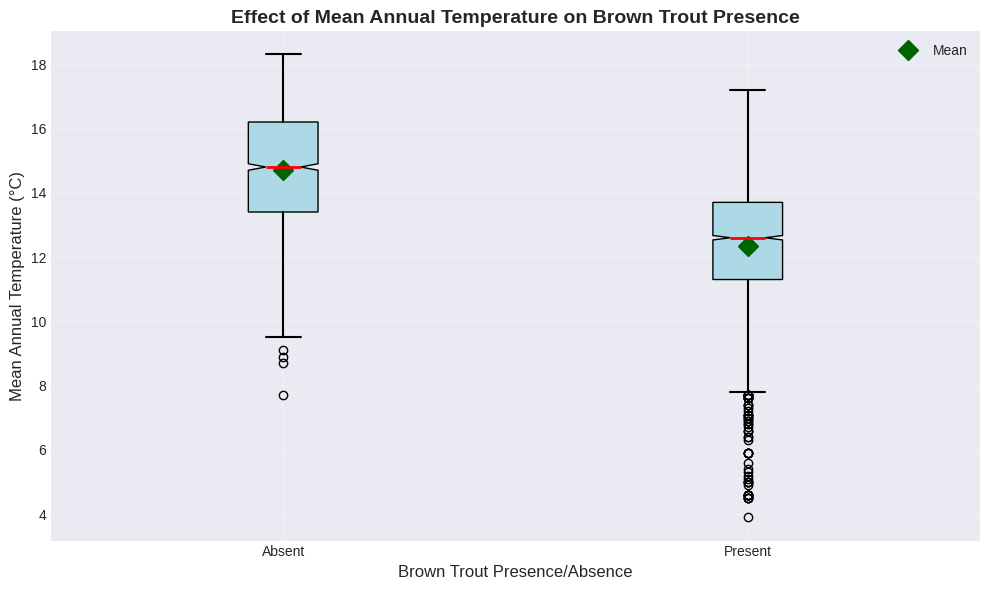


--- Temperature Summary Statistics ---
         count   mean   std  median  min   max
Absent    1900  14.69  1.78    14.8  7.7  18.3
Present   2941  12.34  1.88    12.6  3.9  17.2

T-test results:
T-statistic: 43.960
P-value: 0.000000
Mean difference: -2.36°C
Conclusion: Significant temperature difference between presence and absence sites


In [10]:
# 1. Explore how Mean Annual Temperature affects Brown Trout presence

# Check the columns - the column name might have dots instead of spaces
print("Column names:")
print(df.columns.tolist())

# The brown trout column is likely 'Salmo trutta fario' but with dots
# Let's find the correct column name
trout_col = [col for col in df.columns if 'Salmo' in col and 'trutta' in col][0]
print(f"\nBrown trout column: {trout_col}")

# Create a binary presence/absence column
df['trout_present'] = df[trout_col].astype(int)

# Check distribution
print("\nBrown Trout presence distribution:")
print(df['trout_present'].value_counts())
print(f"Percentage present: {df['trout_present'].mean()*100:.1f}%")

# Create boxplot
plt.figure(figsize=(10, 6))
box_data = [df[df['trout_present'] == 0]['temp_ann'].dropna(),
            df[df['trout_present'] == 1]['temp_ann'].dropna()]

bp = plt.boxplot(box_data, labels=['Absent', 'Present'],
                 patch_artist=True, notch=True,
                 boxprops=dict(facecolor='lightblue'),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))

# Add means as points
means = [df[df['trout_present'] == 0]['temp_ann'].mean(),
         df[df['trout_present'] == 1]['temp_ann'].mean()]
plt.plot([1, 2], means, 'gD', markersize=10, label='Mean', color='darkgreen')

plt.title('Effect of Mean Annual Temperature on Brown Trout Presence', fontsize=14, fontweight='bold')
plt.xlabel('Brown Trout Presence/Absence', fontsize=12)
plt.ylabel('Mean Annual Temperature (°C)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate summary statistics
print("\n--- Temperature Summary Statistics ---")
summary = df.groupby('trout_present')['temp_ann'].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
summary.index = ['Absent', 'Present']
print(summary.round(2))

# Perform t-test
absent_temp = df[df['trout_present'] == 0]['temp_ann'].dropna()
present_temp = df[df['trout_present'] == 1]['temp_ann'].dropna()

t_stat, p_value = ttest_ind(absent_temp, present_temp, equal_var=False)
print(f"\nT-test results:")
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.6f}")
print(f"Mean difference: {present_temp.mean() - absent_temp.mean():.2f}°C")

if p_value < 0.05:
    print("Conclusion: Significant temperature difference between presence and absence sites")
else:
    print("Conclusion: No significant temperature difference")

Unique catchments:
['Guadalquivir' 'Tejo' 'Douro' 'Segura' 'Jucar' 'Ebro' 'Cantabrica'
 'Guadia' 'Jucar-Ebro' 'Sur' 'Galiza-Norte' 'Minho' 'Galiza-Sul' 'Catala'
 'Segura-Jucar' 'Garonne' 'Rhone' 'South_France_E' 'South_France_W'
 'Corse' 'Ombrone-Tevere' 'Campania-South' 'Tevere' 'Arno-Ombrone'
 'Italia-Veneto' 'Sardinia' 'Ombrone' 'Saline-Pescara-Sangro' 'Oeste'
 'Mira' 'Mondego' 'Odelouca' 'Algarve-Sotavento' 'Algarve-barlavento'
 'Sado' 'Tejo-Sado' 'Vouga' 'EntreDouroeVouga' 'Vouga-Mondego']

Minho catchment: 707 sites
Tejo catchment: 509 sites


/tmp/ipykernel_11315/2059658743.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(data_minho, labels=['Absent', 'Present'], patch_artist=True,
/tmp/ipykernel_11315/2059658743.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "gD" (-> color='g'). The keyword argument will take precedence.
  axes[0].plot([1, 2], means_minho, 'gD', markersize=10, color='darkgreen')
/tmp/ipykernel_11315/2059658743.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_tejo, labels=['Absent', 'Present'], patch_artist=True,
/tmp/ipykernel_11315/2059658743.py:49: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "gD" (-> co

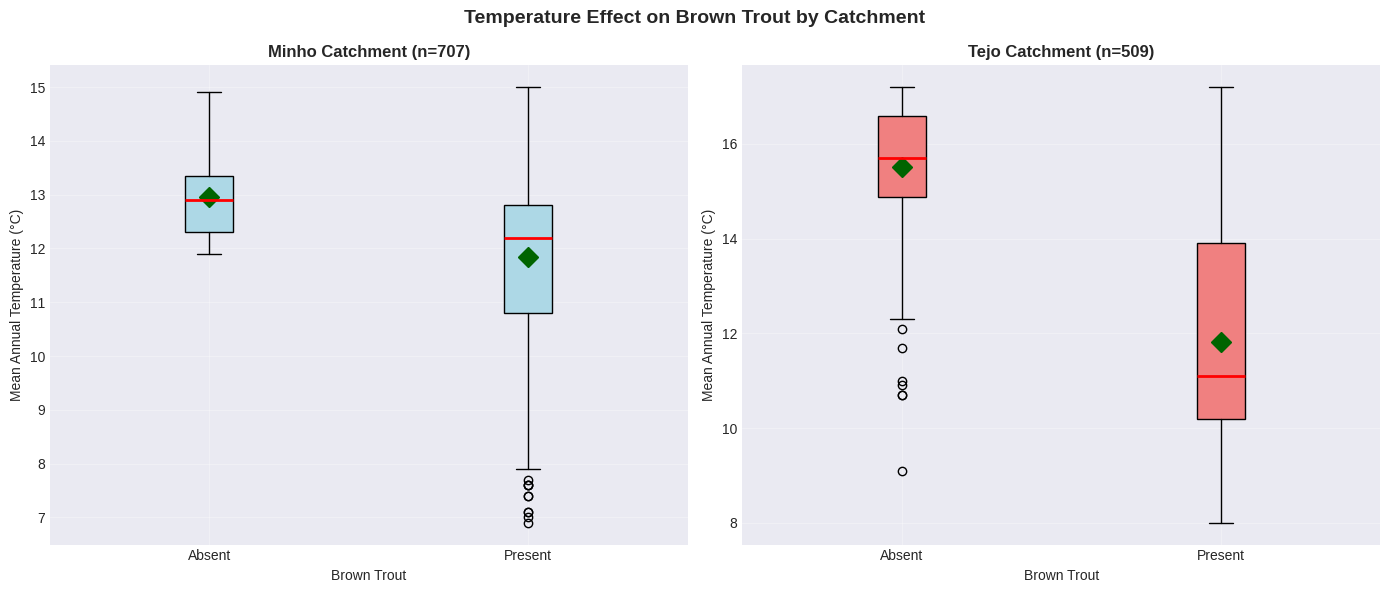


--- Effect Size Analysis ---

Minho Catchment:
  Mean temp (Absent): 12.96°C
  Mean temp (Present): 11.84°C
  Effect size: -1.12°C

Tejo Catchment:
  Mean temp (Absent): 15.51°C
  Mean temp (Present): 11.81°C
  Effect size: -3.70°C

--- T-test for Minho ---
T-statistic: 4.298, P-value: 0.001205

--- T-test for Tejo ---
T-statistic: 20.178, P-value: 0.000000


In [11]:
# 2. Check the same effect for Minho and Tagus catchments separately

# Check unique catchment names
print("Unique catchments:")
print(df['Catchment_name'].unique())

# Filter for our catchments of interest
df_minho = df[df['Catchment_name'] == 'Minho'].copy()
df_tejo = df[df['Catchment_name'] == 'Tejo'].copy()  # Tagus is 'Tejo' in the data

print(f"\nMinho catchment: {len(df_minho)} sites")
print(f"Tejo catchment: {len(df_tejo)} sites")

# Create side-by-side boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Minho plot
data_minho = [df_minho[df_minho['trout_present'] == 0]['temp_ann'].dropna(),
              df_minho[df_minho['trout_present'] == 1]['temp_ann'].dropna()]

bp1 = axes[0].boxplot(data_minho, labels=['Absent', 'Present'], patch_artist=True,
                       boxprops=dict(facecolor='lightblue'),
                       medianprops=dict(color='red', linewidth=2))
axes[0].set_title(f'Minho Catchment (n={len(df_minho)})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Brown Trout')
axes[0].set_ylabel('Mean Annual Temperature (°C)')
axes[0].grid(True, alpha=0.3)

# Add means
means_minho = [df_minho[df_minho['trout_present'] == 0]['temp_ann'].mean(),
               df_minho[df_minho['trout_present'] == 1]['temp_ann'].mean()]
axes[0].plot([1, 2], means_minho, 'gD', markersize=10, color='darkgreen')

# Tejo plot
data_tejo = [df_tejo[df_tejo['trout_present'] == 0]['temp_ann'].dropna(),
             df_tejo[df_tejo['trout_present'] == 1]['temp_ann'].dropna()]

bp2 = axes[1].boxplot(data_tejo, labels=['Absent', 'Present'], patch_artist=True,
                       boxprops=dict(facecolor='lightcoral'),
                       medianprops=dict(color='red', linewidth=2))
axes[1].set_title(f'Tejo Catchment (n={len(df_tejo)})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Brown Trout')
axes[1].set_ylabel('Mean Annual Temperature (°C)')
axes[1].grid(True, alpha=0.3)

# Add means
means_tejo = [df_tejo[df_tejo['trout_present'] == 0]['temp_ann'].mean(),
              df_tejo[df_tejo['trout_present'] == 1]['temp_ann'].mean()]
axes[1].plot([1, 2], means_tejo, 'gD', markersize=10, color='darkgreen')

plt.suptitle('Temperature Effect on Brown Trout by Catchment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate effect sizes
print("\n--- Effect Size Analysis ---")

# Minho catchment
minho_absent = df_minho[df_minho['trout_present'] == 0]['temp_ann'].mean()
minho_present = df_minho[df_minho['trout_present'] == 1]['temp_ann'].mean()
minho_effect = minho_present - minho_absent

print(f"\nMinho Catchment:")
print(f"  Mean temp (Absent): {minho_absent:.2f}°C")
print(f"  Mean temp (Present): {minho_present:.2f}°C")
print(f"  Effect size: {minho_effect:.2f}°C")

# Tejo catchment
tejo_absent = df_tejo[df_tejo['trout_present'] == 0]['temp_ann'].mean()
tejo_present = df_tejo[df_tejo['trout_present'] == 1]['temp_ann'].mean()
tejo_effect = tejo_present - tejo_absent

print(f"\nTejo Catchment:")
print(f"  Mean temp (Absent): {tejo_absent:.2f}°C")
print(f"  Mean temp (Present): {tejo_present:.2f}°C")
print(f"  Effect size: {tejo_effect:.2f}°C")

# T-tests for each catchment
print(f"\n--- T-test for Minho ---")
t_minho, p_minho = ttest_ind(df_minho[df_minho['trout_present'] == 0]['temp_ann'].dropna(),
                              df_minho[df_minho['trout_present'] == 1]['temp_ann'].dropna(),
                              equal_var=False)
print(f"T-statistic: {t_minho:.3f}, P-value: {p_minho:.6f}")

print(f"\n--- T-test for Tejo ---")
t_tejo, p_tejo = ttest_ind(df_tejo[df_tejo['trout_present'] == 0]['temp_ann'].dropna(),
                            df_tejo[df_tejo['trout_present'] == 1]['temp_ann'].dropna(),
                            equal_var=False)
print(f"T-statistic: {t_tejo:.3f}, P-value: {p_tejo:.6f}")

Column names in your dataframe:
['Site_code', 'Latitude', 'Longitude', 'Country', 'Catchment_name', 'Galiza', 'Subsample', 'Calib_EFI_Medit', 'Calib_connect', 'Calib_hydrol', 'Calib_morphol', 'Calib_wqual', 'Geomorph1', 'Geomorph2', 'Geomorph3', 'Water_source_type', 'Flow_regime', 'Altitude', 'Geological_typology', 'Actual_river_slope', 'Natural_sediment', 'Elevation_mean_catch', 'prec_ann_catch', 'temp_ann', 'temp_jan', 'temp_jul', 'Barriers_catchment_down', 'Barriers_river_segment_up', 'Barriers_river_segment_down', 'Barriers_number_river_segment_up', 'Barriers_number_river_segment_down', 'Barriers_distance_river_segment_up', 'Barriers_distance_river_segment_down', 'Impoundment', 'Hydropeaking', 'Water_abstraction', 'Hydro_mod', 'Temperature_impact', 'Velocity_increase', 'Reservoir_flushing', 'Sedimentation', 'Channelisation', 'Cross_sec', 'Instream_habitat', 'Riparian_vegetation', 'Embankment', 'Floodprotection', 'Floodplain', 'Toxic_substances', 'Acidification', 'Water_quality_inde

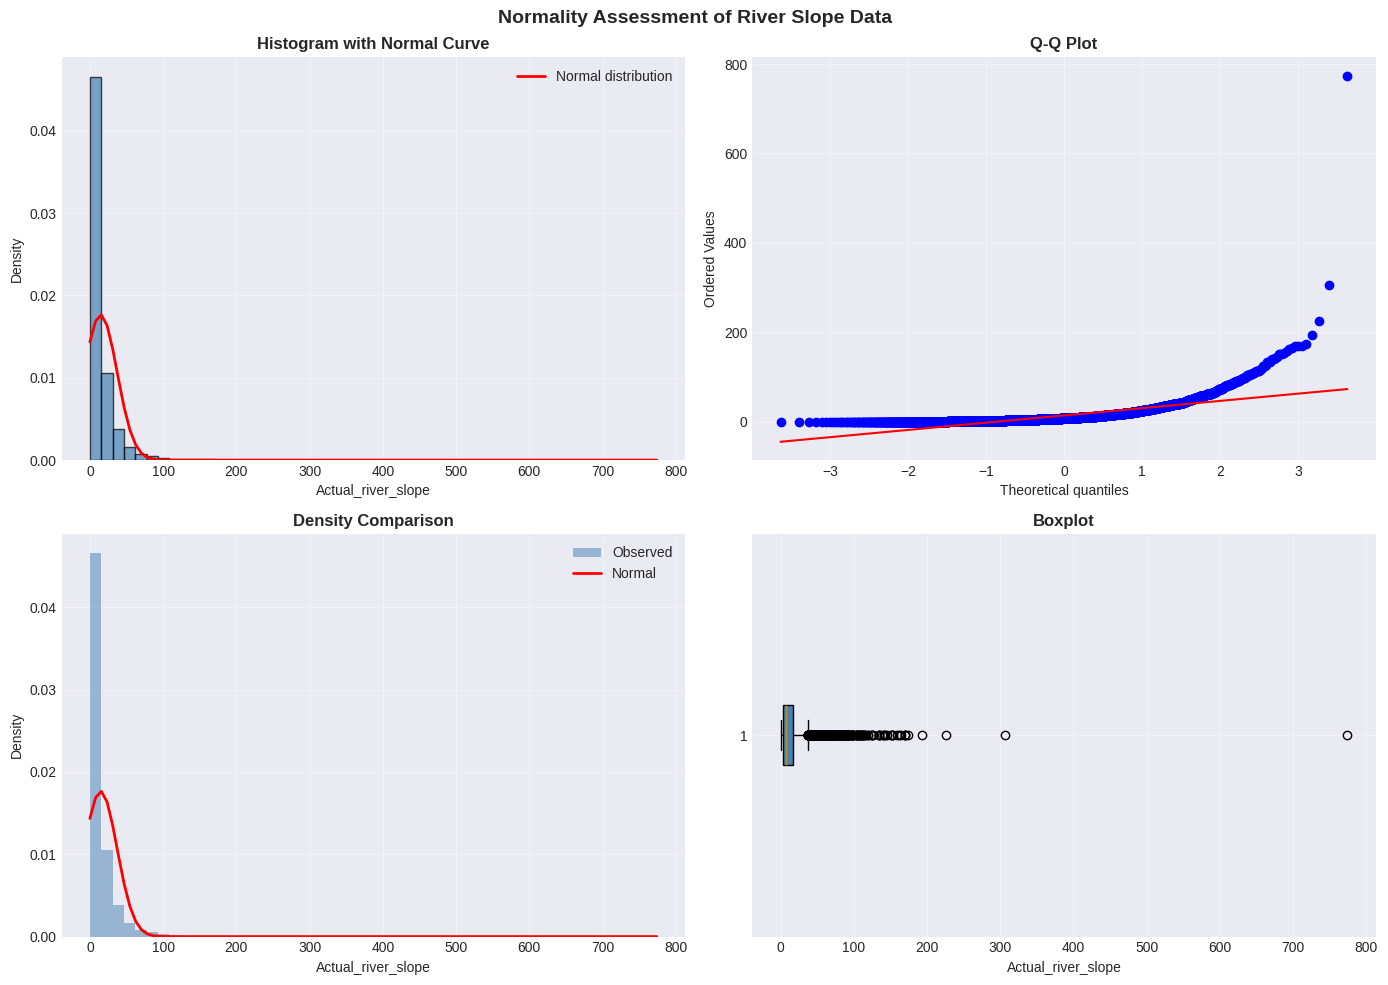


--- Normality Tests ---

Shapiro-Wilk test:
  Statistic: 0.516324
  P-value: 0.000000

Anderson-Darling test:
  Statistic: 541.451447
  Critical values: [0.576 0.655 0.786 0.917 1.091]

--- Interpretation ---
✓ The data is NOT normally distributed (p = 0.000000 < 0.05)


In [14]:
# 3. Test if actual_river_slope is normally distributed

# First, let's see what slope-related columns exist in your dataframe
print("Column names in your dataframe:")
print(df.columns.tolist())

# Find columns related to slope
slope_columns = [col for col in df.columns if 'slope' in col.lower()]
print(f"\nSlope-related columns: {slope_columns}")

# If 'actual_river_slope' doesn't exist, let's use the first slope column we find
if 'actual_river_slope' in df.columns:
    slope_col = 'actual_river_slope'
elif len(slope_columns) > 0:
    slope_col = slope_columns[0]
    print(f"\nUsing '{slope_col}' as the slope column")
else:
    # If no slope column found, let's look at all numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\nNumeric columns available: {numeric_cols}")
    # Ask user to choose or use first numeric column
    slope_col = numeric_cols[0]  # or you can set this manually
    print(f"Using '{slope_col}' as a fallback")

# Get slope data, remove missing values
slope_data = df[slope_col].dropna().values

print(f"\nAnalyzing column: {slope_col}")
print(f"Number of observations: {len(slope_data)}")
print(f"Mean: {np.mean(slope_data):.4f}")
print(f"Std Dev: {np.std(slope_data):.4f}")
print(f"Min: {np.min(slope_data):.4f}")
print(f"Max: {np.max(slope_data):.4f}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram
axes[0, 0].hist(slope_data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='black')
x = np.linspace(min(slope_data), max(slope_data), 100)
axes[0, 0].plot(x, stats.norm.pdf(x, np.mean(slope_data), np.std(slope_data)),
                'r-', linewidth=2, label='Normal distribution')
axes[0, 0].set_title('Histogram with Normal Curve', fontweight='bold')
axes[0, 0].set_xlabel(slope_col)
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot
stats.probplot(slope_data, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Density plot
axes[1, 0].hist(slope_data, bins=50, density=True, alpha=0.5, color='steelblue', label='Observed')
axes[1, 0].plot(x, stats.norm.pdf(x, np.mean(slope_data), np.std(slope_data)),
                'r-', linewidth=2, label='Normal')
axes[1, 0].set_title('Density Comparison', fontweight='bold')
axes[1, 0].set_xlabel(slope_col)
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Boxplot
axes[1, 1].boxplot(slope_data, vert=False, patch_artist=True, boxprops=dict(facecolor='steelblue'))
axes[1, 1].set_title('Boxplot', fontweight='bold')
axes[1, 1].set_xlabel(slope_col)
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Normality Assessment of River Slope Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Normality tests
print("\n--- Normality Tests ---")

# Shapiro-Wilk test
if len(slope_data) <= 5000:
    shapiro_stat, shapiro_p = shapiro(slope_data)
    print(f"\nShapiro-Wilk test:")
    print(f"  Statistic: {shapiro_stat:.6f}")
    print(f"  P-value: {shapiro_p:.6f}")
else:
    # Take a random sample of 5000
    np.random.seed(123)
    sample_slope = np.random.choice(slope_data, size=5000, replace=False)
    shapiro_stat, shapiro_p = shapiro(sample_slope)
    print(f"\nShapiro-Wilk test (on 5000 random samples):")
    print(f"  Statistic: {shapiro_stat:.6f}")
    print(f"  P-value: {shapiro_p:.6f}")

# Anderson-Darling test
anderson_result = anderson(slope_data, dist='norm')
print(f"\nAnderson-Darling test:")
print(f"  Statistic: {anderson_result.statistic:.6f}")
print(f"  Critical values: {anderson_result.critical_values}")

# Interpretation
print("\n--- Interpretation ---")
alpha = 0.05
if shapiro_p < alpha:
    print(f"✓ The data is NOT normally distributed (p = {shapiro_p:.6f} < 0.05)")
else:
    print(f"✗ The data MAY be normally distributed (p = {shapiro_p:.6f} > 0.05)")


Taking 100 samples of size 2000...
Completed 10 samples
Completed 20 samples
Completed 30 samples
Completed 40 samples
Completed 50 samples
Completed 60 samples
Completed 70 samples
Completed 80 samples
Completed 90 samples
Completed 100 samples

Sample Means Summary:
Mean of sample means: 14.482090
SD of sample means: 0.471588
Original population mean: 14.582432


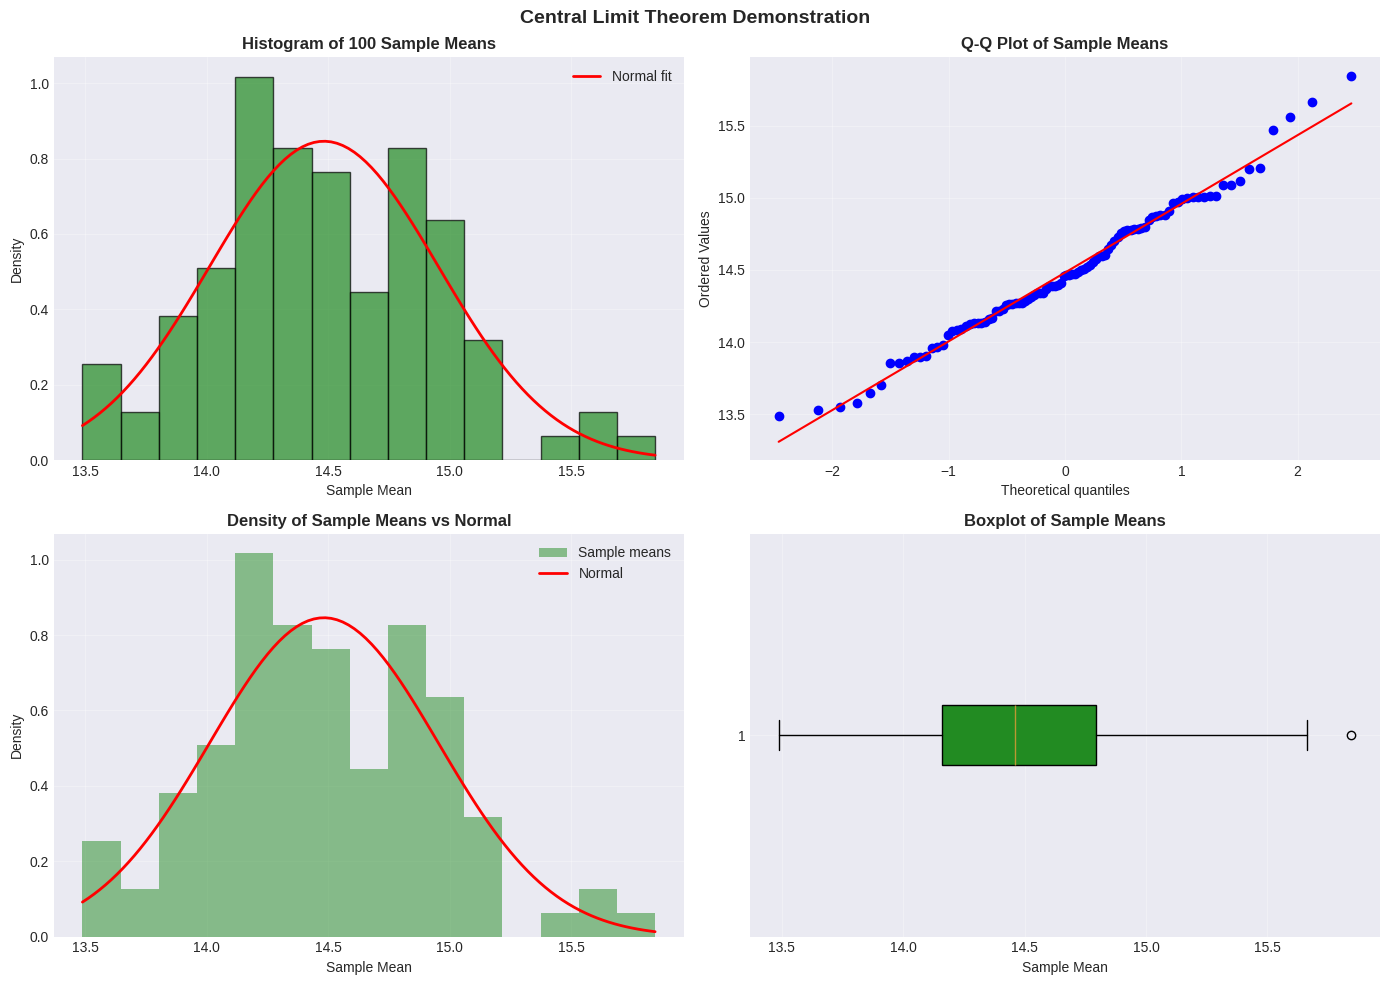


--- Normality Tests on Sample Means ---

Shapiro-Wilk test on sample means:
  Statistic: 0.986884
  P-value: 0.429871

--- Comparison with Original Data ---
Original data p-value: 0.000000
Sample means p-value: 0.429871

✓ The Central Limit Theorem is demonstrated!
  Even though the original data is not normal,
  the distribution of sample means IS normal.


In [15]:
# 4. Take 100 samples of 2000 observations with replacement

if len(slope_data) < 2000:
    print(f"Note: Only {len(slope_data)} observations available.")
    sample_size = min(500, len(slope_data) // 2)
else:
    sample_size = 2000

np.random.seed(123)  # For reproducibility

n_samples = 100
sample_means = []

print(f"\nTaking {n_samples} samples of size {sample_size}...")

for i in range(n_samples):
    # Sample with replacement
    sample = np.random.choice(slope_data, size=sample_size, replace=True)
    sample_means.append(np.mean(sample))

    if (i + 1) % 10 == 0:
        print(f"Completed {i + 1} samples")

sample_means = np.array(sample_means)

print(f"\nSample Means Summary:")
print(f"Mean of sample means: {np.mean(sample_means):.6f}")
print(f"SD of sample means: {np.std(sample_means, ddof=1):.6f}")
print(f"Original population mean: {np.mean(slope_data):.6f}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of sample means
axes[0, 0].hist(sample_means, bins=15, density=True, alpha=0.7, color='forestgreen', edgecolor='black')
x = np.linspace(min(sample_means), max(sample_means), 100)
axes[0, 0].plot(x, stats.norm.pdf(x, np.mean(sample_means), np.std(sample_means, ddof=1)),
                'r-', linewidth=2, label='Normal fit')
axes[0, 0].set_title('Histogram of 100 Sample Means', fontweight='bold')
axes[0, 0].set_xlabel('Sample Mean')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot of sample means
stats.probplot(sample_means, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot of Sample Means', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# 3. Density plot comparison
axes[1, 0].hist(sample_means, bins=15, density=True, alpha=0.5, color='forestgreen', label='Sample means')
axes[1, 0].plot(x, stats.norm.pdf(x, np.mean(sample_means), np.std(sample_means, ddof=1)),
                'r-', linewidth=2, label='Normal')
axes[1, 0].set_title('Density of Sample Means vs Normal', fontweight='bold')
axes[1, 0].set_xlabel('Sample Mean')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Boxplot of sample means
axes[1, 1].boxplot(sample_means, vert=False, patch_artist=True, boxprops=dict(facecolor='forestgreen'))
axes[1, 1].set_title('Boxplot of Sample Means', fontweight='bold')
axes[1, 1].set_xlabel('Sample Mean')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Central Limit Theorem Demonstration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Normality tests on sample means
print("\n--- Normality Tests on Sample Means ---")

shapiro_stat_m, shapiro_p_m = shapiro(sample_means)
print(f"\nShapiro-Wilk test on sample means:")
print(f"  Statistic: {shapiro_stat_m:.6f}")
print(f"  P-value: {shapiro_p_m:.6f}")

# Compare with original data
print("\n--- Comparison with Original Data ---")
print(f"Original data p-value: {shapiro_p:.6f}")
print(f"Sample means p-value: {shapiro_p_m:.6f}")

if shapiro_p_m > 0.05:
    print("\n✓ The Central Limit Theorem is demonstrated!")
    print("  Even though the original data is not normal,")
    print("  the distribution of sample means IS normal.")
else:
    print("\n✗ The sample means are still not normal.")
    print("  This might be due to extreme skewness or small sample size.")